In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install timm torch torchvision
import torch
import timm
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [ ]:
train_dir = "/content/drive/MyDrive/Poultry/dataset/train"
val_dir   = "/content/drive/MyDrive/Poultry/dataset/val"
test_dir  = "/content/drive/MyDrive/Poultry/dataset/test"

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds = datasets.ImageFolder(val_dir, transform=transform)
test_ds = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)


print("Number of training images   :", len(train_ds))
print("Number of validation images :", len(val_ds))
print("Number of testing images    :", len(test_ds))

# Total
print("Total images :", len(train_ds) + len(val_ds) + len(test_ds))


Number of training images   : 4260
Number of validation images : 409
Number of testing images    : 202
Total images : 4871


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# CONFIG
# ==========================================
batch_size = 16
epochs = 30
num_classes = len(train_ds.classes)

NUM_WORKERS = 2

# ==========================================
# DATALOADERS
# ==========================================
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# ==========================================
# SE BLOCK
# ==========================================
class SEBlock(nn.Module):

    def __init__(self, in_channels, reduction=16):
        super().__init__()

        hidden = max(in_channels // reduction, 1)

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                in_channels,
                hidden,
                kernel_size=1,
                bias=True
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden,
                in_channels,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x)


# ==========================================
# LOAD PRETRAINED ViT
# ==========================================
vit_model = timm.create_model(
    "vit_base_patch32_224",
    pretrained=True,
    num_classes=num_classes
)

# ==========================================
# INSERT SE BLOCK
# ==========================================
orig_proj = vit_model.patch_embed.proj

embed_dim = orig_proj.out_channels

vit_model.patch_embed.proj = nn.Sequential(
    orig_proj,
    SEBlock(
        in_channels=embed_dim,
        reduction=16
    )
)

# ==========================================
# CUSTOM CLASSIFIER HEAD
# ==========================================
in_features = vit_model.head.in_features

vit_model.head = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.GELU(),
    nn.Dropout(0.4),

    nn.Linear(256, 128),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(128, num_classes)
)

model = vit_model.to(device)

# ==========================================
# LOSS
# ==========================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ==========================================
# DIFFERENTIAL LEARNING RATE
# ==========================================

# Pretrained ViT parameters
backbone_params = []
head_params = []

for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith("head") or "patch_embed.proj.1" in name:
        head_params.append(param)

    else:
        backbone_params.append(param)


optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": 3e-5
        },
        {
            "params": head_params,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

# ==========================================
# COSINE LR SCHEDULER
# ==========================================
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)

# ==========================================
# MODERN AMP
# ==========================================
scaler = torch.amp.GradScaler("cuda")

# ==========================================
# HISTORY
# ==========================================
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# ==========================================
# BEST MODEL
# ==========================================
best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0

patience = 7
patience_counter = 0

# ==========================================
# TRAINING
# ==========================================
for epoch in range(epochs):

    # ==================================================
    # TRAIN
    # ==================================================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        # ---------------- AMP ----------------
        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        # ---------------- BACKPROP ----------------
        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        # ---------------- METRICS ----------------
        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        correct /
        total
    )

    # ==================================================
    # VALIDATION
    # ==================================================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )

    # ==================================================
    # SAVE HISTORY
    # ==================================================
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # ==================================================
    # CURRENT LR
    # ==================================================
    current_lr = optimizer.param_groups[0]["lr"]

    # ==================================================
    # PRINT
    # ==================================================
    print(
        f"Epoch [{epoch+1:02d}/{epochs}] "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  | "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.4f}  | "
        f"LR: {current_lr:.2e}"
    )

    # ==================================================
    # SAVE BEST MODEL
    # ==================================================
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch + 1

        patience_counter = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss,
                "classes": train_ds.classes
            },
            "best_vit_model.pth"
        )

        print(
            f"  >>> Best model saved! "
            f"Val Acc: {val_acc:.4f}"
        )

    else:

        patience_counter += 1

    # ==================================================
    # SCHEDULER
    # ==================================================
    scheduler.step()

    # ==================================================
    # EARLY STOPPING
    # ==================================================
    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch+1}"
        )

        break


# ==========================================
# FINAL RESULT
# ==========================================
print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(
    f"Best Epoch     : {best_epoch}"
)

print(
    f"Best Val Loss  : {best_val_loss:.4f}"
)

print(
    f"Best Val Acc   : {best_val_acc:.4f}"
)

print(
    f"Best Val Acc % : {best_val_acc * 100:.2f}%"
)

print("=" * 60)

Using device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch [01/30] Train Loss: 0.7276  Train Acc: 0.8488  | Val Loss: 0.5692  Val Acc: 0.9218  | LR: 3.00e-05
  >>> Best model saved! Val Acc: 0.9218
Epoch [02/30] Train Loss: 0.4670  Train Acc: 0.9765  | Val Loss: 0.6767  Val Acc: 0.8949  | LR: 2.99e-05
Epoch [03/30] Train Loss: 0.4335  Train Acc: 0.9908  | Val Loss: 0.5412  Val Acc: 0.9438  | LR: 2.97e-05
  >>> Best model saved! Val Acc: 0.9438
Epoch [04/30] Train Loss: 0.4183  Train Acc: 0.9962  | Val Loss: 0.4858  Val Acc: 0.9633  | LR: 2.93e-05
  >>> Best model saved! Val Acc: 0.9633
Epoch [05/30] Train Loss: 0.4131  Train Acc: 0.9981  | Val Loss: 0.5225  Val Acc: 0.9487  | LR: 2.87e-05
Epoch [06/30] Train Loss: 0.4062  Train Acc: 0.9993  | Val Loss: 0.4943  Val Acc: 0.9584  | LR: 2.81e-05
Epoch [07/30] Train Loss: 0.4074  Train Acc: 0.9981  | Val Loss: 0.4977  Val Acc: 0.9609  | LR: 2.72e-05
Epoch [08/30] Train Loss: 0.4089  Train Acc: 0.9969  | Val Loss: 0.4844  Val Acc: 0.9731  | LR: 2.63e-05
  >>> Best model saved! Val Acc: 0.9731


In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


Exact Validation Accuracy: 0.9535


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9505


# ***Swin Tranformer***

In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)
outputs = model(images)

print("Images :", images.shape)
print("Labels :", labels.shape)
print("Output :", outputs.shape)

Images : torch.Size([16, 3, 224, 224])
Labels : torch.Size([16])
Output : torch.Size([16, 7, 7, 5])


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader


# ==========================================
# DEVICE
# ==========================================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ==========================================
# CONFIGURATION
# ==========================================
batch_size = 16
epochs = 30

num_classes = len(train_ds.classes)

NUM_WORKERS = 2

print("Number of classes:", num_classes)
print("Classes:", train_ds.classes)


# ==========================================
# DATALOADERS
# ==========================================
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ==========================================
# SWIN CLASSIFIER
# ==========================================
class SwinClassifier(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # --------------------------------------
        # Pretrained Swin Backbone
        # --------------------------------------
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0
        )

        # Swin feature dimension
        in_features = self.backbone.num_features

        # --------------------------------------
        # Custom Classification Head
        # --------------------------------------
        self.head = nn.Sequential(

            nn.Linear(
                in_features,
                256
            ),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(self, x):

        # --------------------------------------
        # Extract Swin features
        # --------------------------------------
        x = self.backbone.forward_features(x)

        # --------------------------------------
        # Swin Tiny output:
        #
        # [Batch, Height, Width, Channels]
        #
        # Example:
        # [16, 7, 7, 768]
        # --------------------------------------

        if x.ndim == 4:

            x = x.mean(
                dim=(1, 2)
            )

        # --------------------------------------
        # Classification
        # --------------------------------------
        x = self.head(x)

        return x


# ==========================================
# CREATE MODEL
# ==========================================
model = SwinClassifier(
    num_classes=num_classes
).to(device)


# ==========================================
# CHECK OUTPUT SHAPE
# ==========================================
print("\nChecking model output shape...")

sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

with torch.no_grad():

    sample_outputs = model(
        sample_images
    )

print(
    "Images :", sample_images.shape
)

print(
    "Labels :", sample_labels.shape
)

print(
    "Output :", sample_outputs.shape
)


# ==========================================
# OUTPUT VALIDATION
# ==========================================
expected_shape = (
    sample_images.size(0),
    num_classes
)

if tuple(sample_outputs.shape) != expected_shape:

    raise RuntimeError(
        f"Wrong output shape! "
        f"Expected {expected_shape}, "
        f"but got {tuple(sample_outputs.shape)}"
    )

print(
    "Output shape check: PASSED"
)


# ==========================================
# LOSS FUNCTION
# ==========================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ==========================================
# DIFFERENTIAL LEARNING RATE
# ==========================================
backbone_params = []
head_params = []


for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith("head"):

        head_params.append(param)

    else:

        backbone_params.append(param)


optimizer = torch.optim.AdamW(

    [
        {
            "params": backbone_params,
            "lr": 3e-5
        },

        {
            "params": head_params,
            "lr": 1e-4
        }
    ],

    weight_decay=1e-4
)


# ==========================================
# COSINE LR SCHEDULER
# ==========================================
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=epochs,

    eta_min=1e-6
)


# ==========================================
# AMP
# ==========================================
scaler = torch.amp.GradScaler(
    "cuda"
)


# ==========================================
# HISTORY
# ==========================================
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ==========================================
# BEST MODEL
# ==========================================
best_val_acc = 0.0

best_val_loss = float("inf")

best_epoch = 0

patience = 7

patience_counter = 0


# ==========================================
# TRAINING LOOP
# ==========================================
for epoch in range(epochs):


    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        # ----------------------------------------------
        # Move data to GPU
        # ----------------------------------------------

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------
        # Clear gradients
        # ----------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------
        # Forward + Loss
        # ----------------------------------------------

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------
        # Backward
        # ----------------------------------------------

        scaler.scale(
            loss
        ).backward()


        # ----------------------------------------------
        # Gradient Clipping
        # ----------------------------------------------

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------
        # Optimizer Step
        # ----------------------------------------------

        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------
        # Metrics
        # ----------------------------------------------

        running_loss += loss.item()


        predictions = outputs.argmax(
            dim=1
        )


        total += labels.size(0)


        correct += (
            predictions == labels
        ).sum().item()


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )


    train_acc = (
        correct /
        total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            val_total += labels.size(0)


            val_correct += (
                predictions == labels
            ).sum().item()


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )


    val_acc = (
        val_correct /
        val_total
    )


    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_acc
    )


    # ==================================================
    # CURRENT LR
    # ==================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  | "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.4f}  | "
        f"LR: {current_lr:.2e}"
    )

    # ==================================================
    # SAVE BEST MODEL
    # ==================================================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save(

            {
                "epoch":epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict":  optimizer.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss,
                "classes": train_ds.classes
            },
            "best_swin_model.pth"
        )


        print(
            f"  >>> Best Swin model saved! "
            f"Val Acc: "
            f"{val_acc * 100:.2f}%"
        )


    else:

        patience_counter += 1


    # ==================================================
    # LR SCHEDULER
    # ==================================================

    scheduler.step()
    if patience_counter >= patience:

        print(

            f"\nEarly stopping at epoch "
            f"{epoch + 1}"

        )

        break


# ==========================================
# FINAL RESULT
# ==========================================
print("\n" + "=" * 60)

print("SWIN TRAINING COMPLETED")

print("=" * 60)


print(
    f"Best Epoch     : "
    f"{best_epoch}"
)


print(
    f"Best Val Loss  : "
    f"{best_val_loss:.4f}"
)


print(
    f"Best Val Acc   : "
    f"{best_val_acc:.4f}"
)


print(
    f"Best Val Acc % : "
    f"{best_val_acc * 100:.2f}%"
)


print("=" * 60)

Using device: cuda
Number of classes: 5
Classes: ['Bumblefoot', 'Fowlpox', 'Healthy', 'coryza', 'crd']

Checking model output shape...
Images : torch.Size([16, 3, 224, 224])
Labels : torch.Size([16])
Output : torch.Size([16, 5])
Output shape check: PASSED
Epoch [01/30] Train Loss: 0.8491  Train Acc: 0.7808  | Val Loss: 0.5975  Val Acc: 0.9169  | LR: 3.00e-05
  >>> Best Swin model saved! Val Acc: 91.69%
Epoch [02/30] Train Loss: 0.5330  Train Acc: 0.9498  | Val Loss: 0.5827  Val Acc: 0.9218  | LR: 2.99e-05
  >>> Best Swin model saved! Val Acc: 92.18%
Epoch [03/30] Train Loss: 0.4667  Train Acc: 0.9796  | Val Loss: 0.5377  Val Acc: 0.9487  | LR: 2.97e-05
  >>> Best Swin model saved! Val Acc: 94.87%
Epoch [04/30] Train Loss: 0.4430  Train Acc: 0.9876  | Val Loss: 0.5350  Val Acc: 0.9438  | LR: 2.93e-05
Epoch [05/30] Train Loss: 0.4283  Train Acc: 0.9920  | Val Loss: 0.5147  Val Acc: 0.9535  | LR: 2.87e-05
  >>> Best Swin model saved! Val Acc: 95.35%
Epoch [06/30] Train Loss: 0.4212  Train

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


Exact Validation Accuracy: 0.9609


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9653


# ***ConvNeXt V2***

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


Exact Validation Accuracy: 0.9584


In [ ]:
# ============================================================
# CONVNEXT V2 - FIXED FULL TRAINING CODE
# ============================================================

import torch
import torch.nn as nn
import timm

from torch.utils.data import DataLoader


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 16
EPOCHS = 30
NUM_WORKERS = 2

num_classes = len(train_ds.classes)

print("Number of classes:", num_classes)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ============================================================
# LOAD PRETRAINED CONVNEXT V2
# ============================================================

model = timm.create_model(
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    pretrained=True,
    num_classes=0
)


# ============================================================
# FEATURE DIMENSION
# ============================================================

in_features = model.num_features

print("Feature dimension:", in_features)


# ============================================================
# CUSTOM CLASSIFIER HEAD
# IMPORTANT:
# ConvNeXt V2 outputs [B, 768, 7, 7]
# Therefore AdaptiveAvgPool2d is required.
# ============================================================

model.head = nn.Sequential(

    # [B, 768, 7, 7]
    nn.AdaptiveAvgPool2d(1),

    # [B, 768, 1, 1] -> [B, 768]
    nn.Flatten(),

    # Classifier
    nn.Linear(
        in_features,
        256
    ),

    nn.GELU(),

    nn.Dropout(0.4),

    nn.Linear(
        256,
        128
    ),

    nn.GELU(),

    nn.Dropout(0.3),

    nn.Linear(
        128,
        num_classes
    )
)


# ============================================================
# MOVE TO GPU
# ============================================================

model = model.to(device)


# ============================================================
# CHECK OUTPUT SHAPE
# ============================================================

print("\nChecking model output shape...")

with torch.no_grad():

    dummy_input = torch.randn(
        2,
        3,
        224,
        224
    ).to(device)

    dummy_output = model(
        dummy_input
    )

print(
    "Input shape :",
    dummy_input.shape
)

print(
    "Output shape:",
    dummy_output.shape
)

assert dummy_output.shape == (
    2,
    num_classes
), (
    f"Unexpected output shape: "
    f"{dummy_output.shape}"
)

print("Output shape is correct!")


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ============================================================
# DIFFERENTIAL LEARNING RATE
# ============================================================

backbone_params = []
head_params = []


for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith("head"):

        head_params.append(param)

    else:

        backbone_params.append(param)


optimizer = torch.optim.AdamW(

    [
        {
            "params": backbone_params,
            "lr": 3e-5
        },

        {
            "params": head_params,
            "lr": 1e-4
        }
    ],

    weight_decay=1e-4
)


# ============================================================
# COSINE LR SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS,

    eta_min=1e-6
)


# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler("cuda")


# ============================================================
# HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ============================================================
# BEST MODEL
# ============================================================

best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0

patience = 7
patience_counter = 0


# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.amp.autocast("cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(loss).backward()


        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # OPTIMIZER STEP
        # ----------------------------------------------------

        scaler.step(optimizer)

        scaler.update()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        correct /
        total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast("cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )


    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_acc
    )


    # ========================================================
    # CURRENT LR
    # ========================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  | "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.4f}  | "
        f"LR: {current_lr:.2e}"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_val_loss = val_loss

        best_epoch = epoch + 1

        patience_counter = 0


        torch.save(

            {
                "epoch":
                    epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_acc":
                    val_acc,

                "val_loss":
                    val_loss,

                "classes":
                    train_ds.classes

            },

            "best_convnextv2_model.pth"

        )


        print(
            f"  >>> Best ConvNeXt V2 model saved! "
            f"Val Acc: {val_acc:.4f}"
        )


    else:

        patience_counter += 1


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch+1}"
        )

        break


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 60)

print("CONVNEXT V2 TRAINING COMPLETED")

print("=" * 60)

print(
    f"Best Epoch     : "
    f"{best_epoch}"
)

print(
    f"Best Val Loss  : "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Val Acc   : "
    f"{best_val_acc:.4f}"
)

print(
    f"Best Val Acc % : "
    f"{best_val_acc * 100:.2f}%"
)

print("=" * 60)

Using device: cuda
Number of classes: 5
Feature dimension: 768

Checking model output shape...
Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 5])
Output shape is correct!
Epoch [01/30] Train Loss: 0.7873  Train Acc: 0.8162  | Val Loss: 0.5887  Val Acc: 0.9144  | LR: 3.00e-05
  >>> Best ConvNeXt V2 model saved! Val Acc: 0.9144
Epoch [02/30] Train Loss: 0.4960  Train Acc: 0.9704  | Val Loss: 0.5432  Val Acc: 0.9315  | LR: 2.99e-05
  >>> Best ConvNeXt V2 model saved! Val Acc: 0.9315


KeyboardInterrupt: 

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9505


# ***MaxVit- Tiny*** *italicized text*

In [ ]:
# ============================================================
# MAXVIT-TINY - FULL TRAINING CODE
# ============================================================

import torch
import torch.nn as nn
import timm

from torch.utils.data import DataLoader


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 16
EPOCHS = 30
NUM_WORKERS = 2

num_classes = len(train_ds.classes)

print("Number of classes:", num_classes)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ============================================================
# LOAD PRETRAINED MAXVIT-TINY
# ============================================================

model = timm.create_model(
    "maxvit_tiny_tf_224.in1k",
    pretrained=True,
    num_classes=0
)


# ============================================================
# FEATURE DIMENSION
# ============================================================

in_features = model.num_features

print("Feature dimension:", in_features)


# ============================================================
# CUSTOM CLASSIFIER HEAD
# ============================================================

model.head = nn.Sequential(

    # Global average pooling
    nn.AdaptiveAvgPool2d(1),

    # [B, C, 1, 1] -> [B, C]
    nn.Flatten(),

    # Classifier
    nn.Linear(
        in_features,
        256
    ),

    nn.GELU(),

    nn.Dropout(0.4),

    nn.Linear(
        256,
        128
    ),

    nn.GELU(),

    nn.Dropout(0.3),

    nn.Linear(
        128,
        num_classes
    )
)


# ============================================================
# MOVE MODEL TO GPU
# ============================================================

model = model.to(device)


# ============================================================
# OUTPUT SHAPE CHECK
# ============================================================

print("\nChecking model output shape...")

with torch.no_grad():

    dummy_input = torch.randn(
        2,
        3,
        224,
        224
    ).to(device)

    dummy_output = model(
        dummy_input
    )

print(
    "Input shape :",
    dummy_input.shape
)

print(
    "Output shape:",
    dummy_output.shape
)

assert dummy_output.shape == (
    2,
    num_classes
), (
    f"Unexpected output shape: "
    f"{dummy_output.shape}"
)

print("Output shape is correct!")


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ============================================================
# DIFFERENTIAL LEARNING RATE
# ============================================================

backbone_params = []
head_params = []


for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    if name.startswith("head"):

        head_params.append(param)

    else:

        backbone_params.append(param)


optimizer = torch.optim.AdamW(

    [
        {
            "params": backbone_params,
            "lr": 3e-5
        },

        {
            "params": head_params,
            "lr": 1e-4
        }
    ],

    weight_decay=1e-4
)


# ============================================================
# COSINE LR SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS,

    eta_min=1e-6
)


# ============================================================
# MODERN AMP
# ============================================================

scaler = torch.amp.GradScaler("cuda")


# ============================================================
# HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ============================================================
# BEST MODEL
# ============================================================

best_val_acc = 0.0
best_val_loss = float("inf")
best_epoch = 0

patience = 7
patience_counter = 0


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        with torch.amp.autocast(
            "cuda",
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()


        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        # ----------------------------------------------------
        # OPTIMIZER STEP
        # ----------------------------------------------------

        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        correct /
        total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                "cuda",
                enabled=(device.type == "cuda")
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )


    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_acc
    )


    # ========================================================
    # CURRENT LR
    # ========================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(

        f"Epoch [{epoch+1:02d}/{EPOCHS}] "

        f"Train Loss: {train_loss:.4f}  "

        f"Train Acc: {train_acc:.4f}  | "

        f"Val Loss: {val_loss:.4f}  "

        f"Val Acc: {val_acc:.4f}  | "

        f"LR: {current_lr:.2e}"

    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_val_loss = val_loss

        best_epoch = epoch + 1

        patience_counter = 0


        torch.save(

            {
                "epoch":
                    epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_acc":
                    val_acc,

                "val_loss":
                    val_loss,

                "classes":
                    train_ds.classes

            },

            "best_maxvit_tiny_model.pth"

        )


        print(

            f"  >>> Best MaxViT-Tiny model saved! "
            f"Val Acc: {val_acc:.4f}"
        )


    else:

        patience_counter += 1


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch+1}"
        )

        break


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 60)

print("MAXVIT-TINY TRAINING COMPLETED")

print("=" * 60)

print(
    f"Best Epoch     : "
    f"{best_epoch}"
)

print(
    f"Best Val Loss  : "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Val Acc   : "
    f"{best_val_acc:.4f}"
)

print(
    f"Best Val Acc % : "
    f"{best_val_acc * 100:.2f}%"
)

print("=" * 60)

Using device: cuda
Number of classes: 5


model.safetensors: reconstructing file:   0%|          |  0.00B /  124MB            

model.safetensors: downloading bytes:           |  0.00B            

Feature dimension: 512

Checking model output shape...
Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 5])
Output shape is correct!
Epoch [01/30] Train Loss: 1.0148  Train Acc: 0.6918  | Val Loss: 0.6952  Val Acc: 0.8631  | LR: 3.00e-05
  >>> Best MaxViT-Tiny model saved! Val Acc: 0.8631
Epoch [02/30] Train Loss: 0.5728  Train Acc: 0.9371  | Val Loss: 0.5960  Val Acc: 0.9193  | LR: 2.99e-05
  >>> Best MaxViT-Tiny model saved! Val Acc: 0.9193
Epoch [03/30] Train Loss: 0.4714  Train Acc: 0.9838  | Val Loss: 0.5434  Val Acc: 0.9389  | LR: 2.97e-05
  >>> Best MaxViT-Tiny model saved! Val Acc: 0.9389
Epoch [04/30] Train Loss: 0.4441  Train Acc: 0.9920  | Val Loss: 0.5232  Val Acc: 0.9389  | LR: 2.93e-05
Epoch [05/30] Train Loss: 0.4273  Train Acc: 0.9967  | Val Loss: 0.5173  Val Acc: 0.9535  | LR: 2.87e-05
  >>> Best MaxViT-Tiny model saved! Val Acc: 0.9535
Epoch [06/30] Train Loss: 0.4172  Train Acc: 0.9986  | Val Loss: 0.5139  Val Acc: 0.9487  | LR: 2.81e-05
Epoch 

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


Exact Validation Accuracy: 0.9462


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9455


# ***PROPOSED HYBRID ARCHITECTURE***
# ***ViT + SE + Swin-Tiny Feature Fusion***

In [ ]:
# ============================================================
# PROPOSED HYBRID ARCHITECTURE
# ViT + SE + Swin-Tiny Feature Fusion
# ============================================================

import torch
import torch.nn as nn
import timm

from torch.utils.data import DataLoader


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 16
EPOCHS = 30
NUM_WORKERS = 2

num_classes = len(train_ds.classes)

print("Number of classes:", num_classes)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ============================================================
# SE BLOCK
# ============================================================

class SEBlock(nn.Module):

    def __init__(self, in_channels, reduction=16):

        super().__init__()

        hidden = max(
            in_channels // reduction,
            1
        )

        self.fc = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                in_channels,
                hidden,
                kernel_size=1,
                bias=True
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden,
                in_channels,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()
        )


    def forward(self, x):

        return x * self.fc(x)


# ============================================================
# PROPOSED HYBRID MODEL
# ============================================================

class ViT_Swin_Hybrid(nn.Module):

    def __init__(
        self,
        num_classes,
        dropout=0.3
    ):

        super().__init__()


        # ====================================================
        # ViT BRANCH
        # ====================================================

        self.vit = timm.create_model(

            "vit_base_patch32_224",

            pretrained=True,

            num_classes=0
        )


        # ----------------------------------------------------
        # INSERT SE BLOCK AFTER PATCH PROJECTION
        # ----------------------------------------------------

        orig_proj = self.vit.patch_embed.proj

        embed_dim = orig_proj.out_channels


        self.vit.patch_embed.proj = nn.Sequential(

            orig_proj,

            SEBlock(
                in_channels=embed_dim,
                reduction=16
            )
        )


        # ViT feature dimension
        self.vit_dim = self.vit.num_features


        # ====================================================
        # SWIN-TINY BRANCH
        # ====================================================

        self.swin = timm.create_model(

            "swin_tiny_patch4_window7_224",

            pretrained=True,

            num_classes=0
        )


        # Swin feature dimension
        self.swin_dim = self.swin.num_features


        # ====================================================
        # FUSED FEATURE DIMENSION
        # ====================================================

        fusion_dim = (
            self.vit_dim +
            self.swin_dim
        )


        print(
            "ViT feature dimension :",
            self.vit_dim
        )

        print(
            "Swin feature dimension:",
            self.swin_dim
        )

        print(
            "Fusion dimension      :",
            fusion_dim
        )


        # ====================================================
        # FUSION CLASSIFIER
        # ====================================================

        self.fusion = nn.Sequential(

            nn.LayerNorm(
                fusion_dim
            ),

            nn.Linear(
                fusion_dim,
                512
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                512,
                256
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                256,
                num_classes
            )
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ViT FEATURES
        # ----------------------------------------------------

        vit_features = self.vit.forward_features(x)


        # ViT output normally:
        # [B, Tokens, Features]
        #
        # Remove CLS token if present

        if vit_features.dim() == 3:

            vit_features = vit_features[:, 0]

        elif vit_features.dim() == 4:

            vit_features = (
                vit_features
                .mean(dim=(2, 3))
            )


        # ----------------------------------------------------
        # SWIN FEATURES
        # ----------------------------------------------------

        swin_features = self.swin.forward_features(x)


        # Swin may produce:
        # [B, H, W, C]
        #
        # Global average pooling

        if swin_features.dim() == 4:

            swin_features = (
                swin_features
                .mean(dim=(1, 2))
            )

        elif swin_features.dim() == 3:

            swin_features = (
                swin_features
                .mean(dim=1)
            )


        # ----------------------------------------------------
        # FEATURE NORMALIZATION
        # ----------------------------------------------------

        vit_features = nn.functional.normalize(
            vit_features,
            p=2,
            dim=1
        )

        swin_features = nn.functional.normalize(
            swin_features,
            p=2,
            dim=1
        )


        # ----------------------------------------------------
        # FEATURE FUSION
        # ----------------------------------------------------

        fused_features = torch.cat(

            [
                vit_features,
                swin_features
            ],

            dim=1
        )


        # ----------------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------------

        output = self.fusion(
            fused_features
        )


        return output


# ============================================================
# CREATE MODEL
# ============================================================

model = ViT_Swin_Hybrid(
    num_classes=num_classes,
    dropout=0.3
)


model = model.to(device)


# ============================================================
# OUTPUT SHAPE TEST
# ============================================================

print("\nChecking model output...")

with torch.no_grad():

    dummy = torch.randn(
        2,
        3,
        224,
        224
    ).to(device)

    dummy_output = model(
        dummy
    )


print(
    "Input shape :",
    dummy.shape
)

print(
    "Output shape:",
    dummy_output.shape
)


assert dummy_output.shape == (
    2,
    num_classes
), (
    f"Wrong output shape: "
    f"{dummy_output.shape}"
)


print(
    "Output shape is correct!"
)


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ============================================================
# DIFFERENTIAL LEARNING RATE
# ============================================================

vit_params = []
swin_params = []
fusion_params = []


for name, param in model.named_parameters():

    if not param.requires_grad:
        continue


    if name.startswith("vit."):

        vit_params.append(param)


    elif name.startswith("swin."):

        swin_params.append(param)


    elif name.startswith("fusion."):

        fusion_params.append(param)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    [

        {
            "params": vit_params,
            "lr": 2e-5
        },

        {
            "params": swin_params,
            "lr": 2e-5
        },

        {
            "params": fusion_params,
            "lr": 1e-4
        }

    ],

    weight_decay=1e-4
)


# ============================================================
# COSINE LR SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS,

    eta_min=1e-6
)


# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ============================================================
# BEST MODEL
# ============================================================

best_val_acc = 0.0

best_val_loss = float("inf")

best_epoch = 0

patience = 7

patience_counter = 0


# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.amp.autocast(
            "cuda",
            enabled=(device.type == "cuda")
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()


        # ----------------------------------------------------
        # GRADIENT CLIPPING
        # ----------------------------------------------------

        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        running_loss += loss.item()


        predictions = outputs.argmax(
            dim=1
        )


        total += labels.size(0)


        correct += (
            predictions == labels
        ).sum().item()


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )


    train_acc = (
        correct /
        total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    val_running_loss = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:


            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                "cuda",
                enabled=(device.type == "cuda")
            ):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            val_total += labels.size(0)


            val_correct += (
                predictions == labels
            ).sum().item()


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )


    val_acc = (
        val_correct /
        val_total
    )


    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_acc
    )


    # ========================================================
    # LR
    # ========================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(

        f"Epoch [{epoch+1:02d}/{EPOCHS}] "

        f"Train Loss: {train_loss:.4f}  "

        f"Train Acc: {train_acc:.4f}  | "

        f"Val Loss: {val_loss:.4f}  "

        f"Val Acc: {val_acc:.4f}  | "

        f"LR: {current_lr:.2e}"

    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_val_acc:


        best_val_acc = val_acc

        best_val_loss = val_loss

        best_epoch = epoch + 1

        patience_counter = 0


        torch.save(

            {

                "epoch":
                    epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_acc":
                    val_acc,

                "val_loss":
                    val_loss,

                "classes":
                    train_ds.classes

            },

            "best_vit_swin_hybrid.pth"

        )


        print(

            f"  >>> BEST HYBRID MODEL SAVED! "
            f"Val Acc: {val_acc:.4f}"
        )


    else:

        patience_counter += 1


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch+1}"
        )

        break


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 65)

print(
    "PROPOSED ViT + SE + Swin HYBRID "
    "TRAINING COMPLETED"
)

print("=" * 65)

print(
    f"Best Epoch     : "
    f"{best_epoch}"
)

print(
    f"Best Val Loss  : "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Val Acc   : "
    f"{best_val_acc:.4f}"
)

print(
    f"Best Val Acc % : "
    f"{best_val_acc * 100:.2f}%"
)

print("=" * 65)

Using device: cuda
Number of classes: 5
ViT feature dimension : 768
Swin feature dimension: 768
Fusion dimension      : 1536

Checking model output...
Input shape : torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 5])
Output shape is correct!
Epoch [01/30] Train Loss: 0.6838  Train Acc: 0.8615  | Val Loss: 0.5568  Val Acc: 0.9340  | LR: 2.00e-05
  >>> BEST HYBRID MODEL SAVED! Val Acc: 0.9340
Epoch [02/30] Train Loss: 0.4389  Train Acc: 0.9859  | Val Loss: 0.5268  Val Acc: 0.9364  | LR: 1.99e-05
  >>> BEST HYBRID MODEL SAVED! Val Acc: 0.9364
Epoch [03/30] Train Loss: 0.4110  Train Acc: 0.9962  | Val Loss: 0.4789  Val Acc: 0.9584  | LR: 1.98e-05
  >>> BEST HYBRID MODEL SAVED! Val Acc: 0.9584
Epoch [04/30] Train Loss: 0.4032  Train Acc: 0.9977  | Val Loss: 0.4970  Val Acc: 0.9584  | LR: 1.95e-05
Epoch [05/30] Train Loss: 0.4009  Train Acc: 0.9979  | Val Loss: 0.5197  Val Acc: 0.9487  | LR: 1.92e-05
Epoch [06/30] Train Loss: 0.4007  Train Acc: 0.9988  | Val Loss: 0.5031  Val Acc: 

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")


Exact Validation Accuracy: 0.9413


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9455


# ***SWIN + CONVNEXT V2 HYBRID***
# ***GATED FEATURE FUSION***




In [ ]:
# ============================================================
# SWIN + CONVNEXT V2 HYBRID
# GATED FEATURE FUSION
# ============================================================

import torch
import torch.nn as nn
import timm

from torch.utils.data import DataLoader


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 16
EPOCHS = 30
NUM_WORKERS = 2

NUM_CLASSES = len(train_ds.classes)

print("Number of classes:", NUM_CLASSES)
print("Classes:", train_ds.classes)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# ============================================================
# SWIN-TINY BACKBONE
# ============================================================

swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=0
)


# ============================================================
# CONVNEXT V2 BACKBONE
# ============================================================

convnext = timm.create_model(
    "convnextv2_tiny",
    pretrained=True,
    num_classes=0
)


# ============================================================
# FEATURE DIMENSIONS
# ============================================================

swin_dim = swin.num_features
convnext_dim = convnext.num_features

print("Swin feature dimension:", swin_dim)
print("ConvNeXt V2 feature dimension:", convnext_dim)


# ============================================================
# HYBRID MODEL
# ============================================================

class SwinConvNeXtHybrid(nn.Module):

    def __init__(
        self,
        swin,
        convnext,
        swin_dim,
        convnext_dim,
        num_classes
    ):

        super().__init__()

        self.swin = swin
        self.convnext = convnext


        # ----------------------------------------------------
        # Project both feature spaces into same dimension
        # ----------------------------------------------------

        fusion_dim = 384

        self.swin_projection = nn.Sequential(

            nn.Linear(
                swin_dim,
                fusion_dim
            ),

            nn.LayerNorm(fusion_dim),

            nn.GELU(),

            nn.Dropout(0.15)
        )


        self.convnext_projection = nn.Sequential(

            nn.Linear(
                convnext_dim,
                fusion_dim
            ),

            nn.LayerNorm(fusion_dim),

            nn.GELU(),

            nn.Dropout(0.15)
        )


        # ----------------------------------------------------
        # GATED FEATURE FUSION
        # ----------------------------------------------------

        self.gate = nn.Sequential(

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            ),

            nn.GELU(),

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.Sigmoid()
        )


        # ----------------------------------------------------
        # Fusion normalization
        # ----------------------------------------------------

        self.fusion_norm = nn.LayerNorm(
            fusion_dim
        )


        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                256
            ),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # Swin features
        # ----------------------------------------------------

        swin_features = self.swin(x)

        # Safety for spatial outputs
        if swin_features.ndim == 4:

            swin_features = swin_features.mean(
                dim=(2, 3)
            )

        elif swin_features.ndim == 3:

            swin_features = swin_features.mean(
                dim=1
            )


        # ----------------------------------------------------
        # ConvNeXt V2 features
        # ----------------------------------------------------

        conv_features = self.convnext(x)

        # Safety for spatial outputs
        if conv_features.ndim == 4:

            conv_features = conv_features.mean(
                dim=(2, 3)
            )

        elif conv_features.ndim == 3:

            conv_features = conv_features.mean(
                dim=1
            )


        # ----------------------------------------------------
        # Projection
        # ----------------------------------------------------

        swin_features = self.swin_projection(
            swin_features
        )

        conv_features = self.convnext_projection(
            conv_features
        )


        # ----------------------------------------------------
        # Concatenate for gate
        # ----------------------------------------------------

        combined = torch.cat(
            [
                swin_features,
                conv_features
            ],
            dim=1
        )


        # ----------------------------------------------------
        # Learnable gate
        # ----------------------------------------------------

        gate = self.gate(
            combined
        )


        # ----------------------------------------------------
        # Gated fusion
        #
        # gate close to 1:
        #       more Swin
        #
        # gate close to 0:
        #       more ConvNeXt
        # ----------------------------------------------------

        fused = (
            gate * swin_features
            +
            (1.0 - gate) * conv_features
        )


        # ----------------------------------------------------
        # Normalization
        # ----------------------------------------------------

        fused = self.fusion_norm(
            fused
        )


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        output = self.classifier(
            fused
        )


        return output


# ============================================================
# CREATE MODEL
# ============================================================

model = SwinConvNeXtHybrid(
    swin=swin,
    convnext=convnext,
    swin_dim=swin_dim,
    convnext_dim=convnext_dim,
    num_classes=NUM_CLASSES
)

model = model.to(device)


# ============================================================
# CHECK OUTPUT
# ============================================================

model.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(device)

    sample_output = model(
        sample_images
    )

print()
print("Input shape :", sample_images.shape)
print("Output shape:", sample_output.shape)

assert sample_output.shape == (
    sample_images.size(0),
    NUM_CLASSES
)

print("Output shape check: PASSED")


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ============================================================
# DIFFERENTIAL LEARNING RATE
# ============================================================

swin_params = []
convnext_params = []
fusion_params = []


for name, param in model.named_parameters():

    if not param.requires_grad:
        continue


    if name.startswith("swin."):

        swin_params.append(param)


    elif name.startswith("convnext."):

        convnext_params.append(param)


    else:

        fusion_params.append(param)


print()
print("Swin parameters     :", len(swin_params))
print("ConvNeXt parameters :", len(convnext_params))
print("Fusion parameters   :", len(fusion_params))


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    [
        {
            "params": swin_params,
            "lr": 2e-5
        },

        {
            "params": convnext_params,
            "lr": 2e-5
        },

        {
            "params": fusion_params,
            "lr": 1e-4
        }
    ],

    weight_decay=1e-4
)


# ============================================================
# COSINE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS,

    eta_min=1e-6
)


# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler("cuda")


# ============================================================
# HISTORY
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ============================================================
# BEST MODEL
# ============================================================

best_val_acc = 0.0
best_val_loss = float("inf")

best_epoch = 0

patience = 7
patience_counter = 0


# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast("cuda"):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_acc = (
        correct /
        total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast("cuda"):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += loss.item()


            predictions = outputs.argmax(
                dim=1
            )


            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()


    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_acc = (
        val_correct /
        val_total
    )


    # ========================================================
    # HISTORY
    # ========================================================

    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_acc
    )


    # ========================================================
    # CURRENT LR
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]


    # ========================================================
    # PRINT
    # ========================================================

    print(

        f"Epoch [{epoch+1:02d}/{EPOCHS}] "

        f"Train Loss: {train_loss:.4f}  "

        f"Train Acc: {train_acc:.4f}  | "

        f"Val Loss: {val_loss:.4f}  "

        f"Val Acc: {val_acc:.4f}  | "

        f"LR: {current_lr:.2e}"

    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_val_loss = val_loss

        best_epoch = epoch + 1

        patience_counter = 0


        torch.save(

            {
                "epoch":
                    epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_acc":
                    val_acc,

                "val_loss":
                    val_loss,

                "classes":
                    train_ds.classes
            },

            "best_swin_convnext_hybrid.pth"
        )


        print(

            f"  >>> Best Hybrid model saved! "
            f"Val Acc: {val_acc * 100:.2f}%"
        )


    else:

        patience_counter += 1


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= patience:

        print()

        print(
            f"Early stopping at epoch "
            f"{epoch+1}"
        )

        break


# ============================================================
# FINAL RESULT
# ============================================================

print()
print("=" * 65)

print("SWIN + CONVNEXT V2 HYBRID TRAINING COMPLETED")

print("=" * 65)

print(
    f"Best Epoch     : {best_epoch}"
)

print(
    f"Best Val Loss  : {best_val_loss:.4f}"
)

print(
    f"Best Val Acc   : {best_val_acc:.4f}"
)

print(
    f"Best Val Acc % : "
    f"{best_val_acc * 100:.2f}%"
)

print("=" * 65)

Using device: cuda
Number of classes: 5
Classes: ['Bumblefoot', 'Fowlpox', 'Healthy', 'coryza', 'crd']
Swin feature dimension: 768
ConvNeXt V2 feature dimension: 768

Input shape : torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 5])
Output shape check: PASSED

Swin parameters     : 171
ConvNeXt parameters : 198
Fusion parameters   : 20
Epoch [01/30] Train Loss: 0.7935  Train Acc: 0.8263  | Val Loss: 0.5906  Val Acc: 0.9242  | LR: 2.00e-05
  >>> Best Hybrid model saved! Val Acc: 92.42%
Epoch [02/30] Train Loss: 0.4789  Train Acc: 0.9730  | Val Loss: 0.5385  Val Acc: 0.9413  | LR: 1.99e-05
  >>> Best Hybrid model saved! Val Acc: 94.13%
Epoch [03/30] Train Loss: 0.4385  Train Acc: 0.9883  | Val Loss: 0.5354  Val Acc: 0.9413  | LR: 1.98e-05
Epoch [04/30] Train Loss: 0.4216  Train Acc: 0.9937  | Val Loss: 0.5138  Val Acc: 0.9633  | LR: 1.95e-05
  >>> Best Hybrid model saved! Val Acc: 96.33%
Epoch [05/30] Train Loss: 0.4144  Train Acc: 0.9946  | Val Loss: 0.5002  Val Acc: 0.9609 

In [ ]:
# ---- Compute exact validation accuracy ----
model.eval()  # evaluation mode
correct_val = 0
total_val = 0

with torch.no_grad():  # no gradients needed
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_val += labels.size(0)
        correct_val += (predicted == labels).sum().item()

val_accuracy = correct_val / total_val
print(f"Exact Validation Accuracy: {val_accuracy:.4f}")

Exact Validation Accuracy: 0.9633


In [ ]:
# ---- Compute exact test accuracy ----
model.eval()  # set to evaluation mode (disable dropout/batchnorm randomness)
correct_test = 0
total_test = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"Exact Test Accuracy: {test_accuracy:.4f}")

Exact Test Accuracy: 0.9703



HYBRID MODEL - TEST PERFORMANCE
Accuracy          : 0.9703
Macro Precision   : 0.9677
Macro Recall      : 0.9800
Macro F1          : 0.9728
Weighted F1       : 0.9699
Specificity       : 0.9919
ROC-AUC           : 0.9936
MCC               : 0.9597

PER-CLASS PERFORMANCE


,Class,Precision,Recall,F1,Specificity
0,Bumblefoot,1.0000,1.0,1.0000,1.0000
1,Fowlpox,0.9231,1.0,0.9600,0.9947
2,Healthy,0.9730,1.0,0.9863,0.9846
3,coryza,0.9423,1.0,0.9703,0.9804
4,crd,1.0000,0.9,0.9474,1.0000



CONFUSION MATRIX


,Bumblefoot,Fowlpox,Healthy,coryza,crd
Bumblefoot,9,0,0,0,0
Fowlpox,0,12,0,0,0
Healthy,0,0,72,0,0
coryza,0,0,0,49,0
crd,0,1,2,3,54


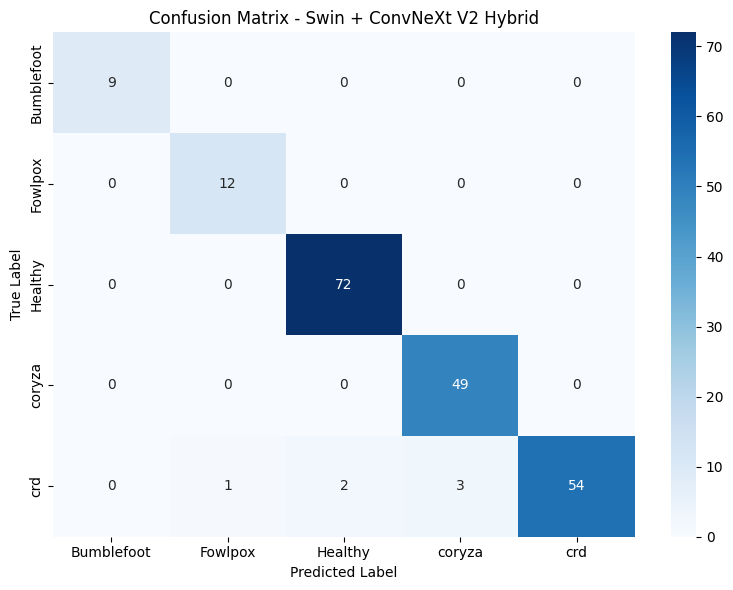

In [ ]:
# ============================================================
# HYBRID MODEL - COMPLETE TEST EVALUATION
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef
)
from sklearn.preprocessing import label_binarize


# ============================================================
# DEVICE & TEST LOADER
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# PREDICTION
# ============================================================

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda"):

            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

classes = train_ds.classes
num_classes = len(classes)


# ============================================================
# MAIN METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true, y_pred
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(num_classes)
)


# ============================================================
# SPECIFICITY
# ============================================================

specificities = []

for i in range(num_classes):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    specificities.append(specificity)


macro_specificity = np.mean(
    specificities
)


# ============================================================
# ROC-AUC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

try:

    roc_auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

except ValueError:

    roc_auc = np.nan


# ============================================================
# PRINT OVERALL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("HYBRID MODEL - TEST PERFORMANCE")
print("=" * 60)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")
print(f"Specificity       : {macro_specificity:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"MCC               : {mcc:.4f}")

print("=" * 60)


# ============================================================
# PER-CLASS METRICS
# ============================================================

per_precision = precision_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(num_classes),
    zero_division=0
)

per_recall = recall_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(num_classes),
    zero_division=0
)

per_f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    labels=np.arange(num_classes),
    zero_division=0
)


per_class_table = pd.DataFrame({

    "Class": classes,

    "Precision": per_precision,

    "Recall": per_recall,

    "F1": per_f1,

    "Specificity": specificities

})


print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE")
print("=" * 60)

display(
    per_class_table.round(4)
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

display(cm_df)


# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Swin + ConvNeXt V2 Hybrid")

plt.tight_layout()
plt.show()

# ***Grad-CAM++***

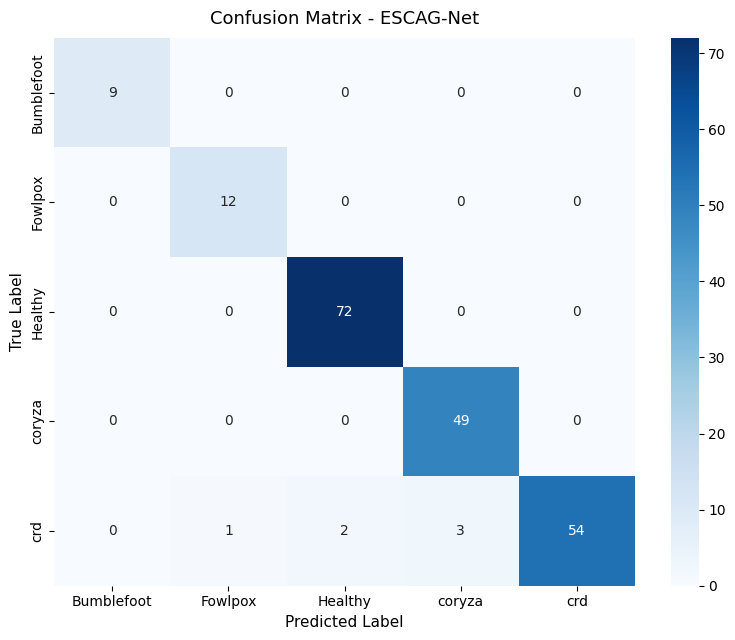

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

cm = np.array(
    [
        [9, 0, 0, 0, 0],
        [0, 12, 0, 0, 0],
        [0, 0, 72, 0, 0],
        [0, 0, 0, 49, 0],
        [0, 1, 2, 3, 54],
    ]
)

labels = ["Bumblefoot", "Fowlpox", "Healthy", "coryza", "crd"]

plt.figure(figsize=(8, 6.5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
)

# ৫. মডেলের নাম অনুযায়ী Title আপডেট করা হয়েছে
plt.title("Confusion Matrix - ESCAG-Net", fontsize=13, pad=10)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

# layout ঠিক করে ছবি সংরক্ষণ ও প্রদর্শন
plt.tight_layout()
plt.savefig("confusion_matrix_escag_net.pdf", dpi=300)
plt.show()

In [ ]:
!pip install grad-cam

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=e1299ccecce63d84534f17d31675c018f63ae76c076fa3a85fba291e39951259
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]
